### imports


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### median filter

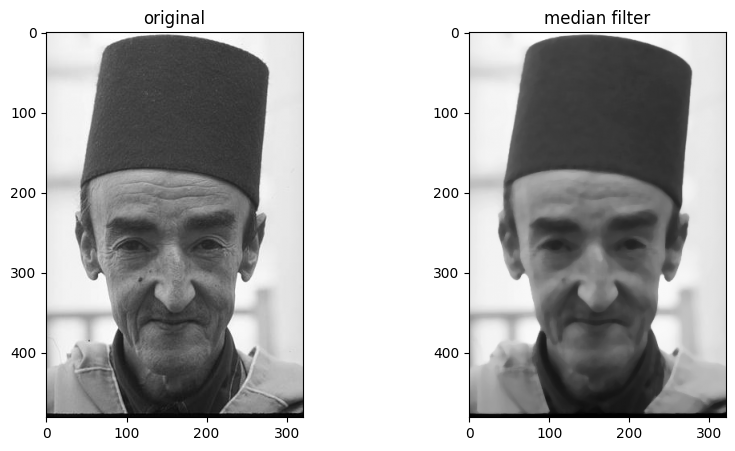

In [2]:
# grayscale to be suitable for filtering
image = cv2.imread('man.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# median filter with kernel size = 7
image_filt=cv2.medianBlur(image_grey, 7)

# display pictures
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("original")
plt.imshow(image_grey, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("median filter")
plt.imshow(image_filt, cmap='gray')
plt.show()

### laplacian filter

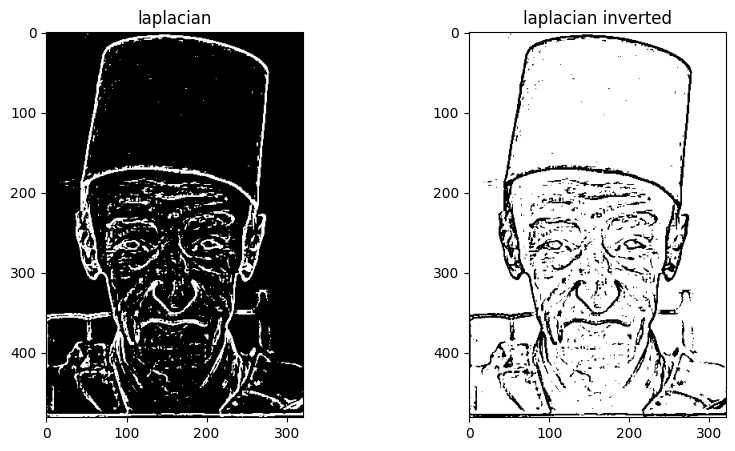

In [ ]:
#apply laplacian filter to find edges
# the larger the kernel size, the thicker the edges bas momkn yo2ady le noise
laplacian = cv2.Laplacian(image_filt, cv2.CV_8U, ksize=5)
# cv2.imshow('laplacian', laplacian)

# any intensity < 80 make it 0 else make it 255
_, laplacian = cv2.threshold(laplacian, 80, 255, cv2.THRESH_BINARY)

laplace_inverted = cv2.bitwise_not(laplacian)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("laplacian")
plt.imshow(laplacian, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("laplacian inverted")
plt.imshow(laplace_inverted, cmap='gray')
plt.show()

### bilateral

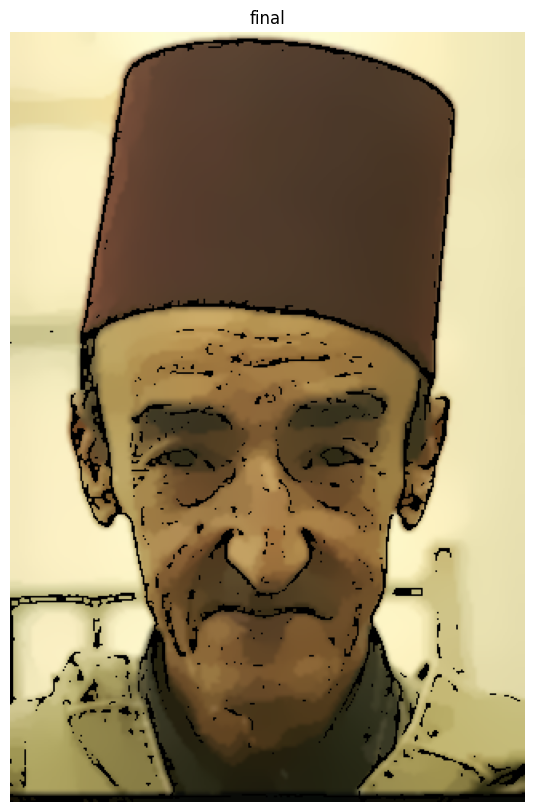

In [ ]:

### Bilateral part
downSampled_img = cv2.pyrDown(image) # downsample to reduce no of pixels and less computation
# number of pixels is 1/4 of total number of pixels
#applying small nilateral filters on downsampled img]
img_bilateral=downSampled_img
# bilateral filter smooths flat areas but keeps edges sharp
# by using spatial distance and intensity difference, keeps edges and smooths the img
# loop is accumulative


upsampled_image = cv2.pyrUp(img_bilateral)

laplace_inverted = cv2.resize(laplace_inverted, (upsampled_image.shape[1], upsampled_image.shape[0]))
cartoonified_image = cv2.bitwise_and(upsampled_image, upsampled_image, mask=laplace_inverted)
cartoonified_image = cv2.cvtColor(cartoonified_image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 10))
plt.title("final")
plt.imshow(cartoonified_image,  cmap='gray')
plt.axis('off') 
plt.show()
